# Phase 4 — Feature Ablation & Model Improvement
### American Express Default Prediction

**Phase 3 recap (treated as source of truth):** on an 80/20 stratified customer-level
holdout (seed 42; 367,130 train / 91,783 validation customers, 25.89% default rate in
both), the full 1,239-feature LightGBM baseline scored ROC AUC 0.9621, AMEX metric 0.7918
(Gini 0.9242, top-4% capture 0.6594), and CatBoost scored AMEX metric 0.7936. In both
models' top-20 feature importance, `_last` features dominated (13/20 LightGBM, 15/20
CatBoost), with `P_2_last` ranked #1 in both.

**Central question:** how much predictive value comes from a customer's *latest* financial
state versus *historical summaries*, *temporal change*, and *missingness information*? The
goal here is not to maximize the validation score — it's to understand which parts of the
Phase 2 feature-engineering pipeline actually earn their place.

**Design:** LightGBM is the primary ablation model — it performed close to CatBoost in
Phase 3, trains far faster, and repeated CatBoost runs would be needlessly expensive for a
controlled experiment. The exact same LightGBM baseline hyperparameters, train/validation
split, AMEX metric implementation, and sparse-feature exclusion policy from Phase 3 are
reused unchanged throughout — no per-experiment tuning, so any metric difference between
experiments reflects the feature set, not the model configuration.


In [1]:
import os
import gc
import re
import time

import numpy as np
import pandas as pd
import psutil
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA_DIR = "../data"
PROCESSED_PATH = os.path.join(DATA_DIR, "processed", "train_features.parquet")
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_SEED = 42

_process = psutil.Process(os.getpid())
def rss_gb():
    return _process.memory_info().rss / 1e9

PHASE4_START = time.time()
print(f"Starting RSS: {rss_gb():.2f} GB")


Starting RSS: 0.16 GB


## Setup: Reproducing the Phase 3 Split and Feature Set Exactly

This block is copied from Phase 3 verbatim (same exclusion list, same split call, same
seed) — not a redesign. `data/processed/train_features.parquet` itself is Phase 2's
output and is not touched or recomputed.


In [2]:
t0 = time.time()
customer_features = pd.read_parquet(PROCESSED_PATH)
print(f"Loaded {customer_features.shape} in {time.time()-t0:.1f}s. RSS: {rss_gb():.2f} GB")

# Same 8-raw-family sparse exclusion policy as Phase 3, applied identically.
DROP_RAW_FAMILIES = ["D_87", "D_88", "D_108", "D_110", "D_111", "B_39", "D_73", "B_42"]
drop_cols = [
    c for c in customer_features.columns
    if any(c == raw or c.startswith(raw + "_") for raw in DROP_RAW_FAMILIES)
]
model_df = customer_features.drop(columns=drop_cols)
del customer_features
gc.collect()
print(f"Sparse-family exclusion: removed {len(drop_cols)} columns -> model_df {model_df.shape}")


Loaded (458913, 1301) in 4.7s. RSS: 1.33 GB


Sparse-family exclusion: removed 60 columns -> model_df (458913, 1241)


In [3]:
TRUE_CATEGORICAL_RAW = ["D_63", "D_64"]
CANDIDATE_CODE_RAW = ["D_116", "D_114", "D_66", "B_31", "D_120", "B_30", "D_126", "B_38", "D_117", "D_68"]
CATEGORICAL_RAW = TRUE_CATEGORICAL_RAW + CANDIDATE_CODE_RAW  # 12, same as Phase 3

categorical_cols = [f"{c}_first" for c in CATEGORICAL_RAW] + [f"{c}_last" for c in CATEGORICAL_RAW]
exclude_cols = ["customer_ID", "target"]
feature_cols = [c for c in model_df.columns if c not in exclude_cols]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

assert set(numeric_cols) | set(categorical_cols) == set(feature_cols)
print(f"Total modeling features (matches Phase 3): {len(feature_cols)}")


Total modeling features (matches Phase 3): 1239


In [4]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    model_df, test_size=0.20, stratify=model_df["target"], random_state=RANDOM_SEED,
)
del model_df
gc.collect()

print(f"Train customers:      {len(train_df):,}  (Phase 3: 367,130)")
print(f"Validation customers: {len(val_df):,}  (Phase 3: 91,783)")
print(f"Train default rate:      {train_df['target'].mean():.4f}  (Phase 3: 0.2589)")
print(f"Validation default rate: {val_df['target'].mean():.4f}  (Phase 3: 0.2589)")

assert len(train_df) == 367_130 and len(val_df) == 91_783, "Split does not match Phase 3 -- stop."
print("\nSplit matches Phase 3 exactly.")


Train customers:      367,130  (Phase 3: 367,130)
Validation customers: 91,783  (Phase 3: 91,783)
Train default rate:      0.2589  (Phase 3: 0.2589)
Validation default rate: 0.2589  (Phase 3: 0.2589)

Split matches Phase 3 exactly.


In [5]:
def amex_metric(y_true, y_pred) -> dict:
    """Official AMEX competition metric -- identical to Phase 3's verified implementation."""
    df = pd.DataFrame({"target": np.asarray(y_true), "prediction": np.asarray(y_pred)})
    df = df.sort_values("prediction", ascending=False).reset_index(drop=True)
    df["weight"] = np.where(df["target"] == 0, 20, 1)

    four_pct_cutoff = int(0.04 * df["weight"].sum())
    df["weight_cumsum"] = df["weight"].cumsum()
    df_cutoff = df.loc[df["weight_cumsum"] <= four_pct_cutoff]
    top4_capture = (df_cutoff["target"] == 1).sum() / (df["target"] == 1).sum()

    def weighted_gini(frame: pd.DataFrame) -> float:
        f = frame.sort_values("prediction", ascending=False)
        f_random = (f["weight"] / f["weight"].sum()).cumsum()
        total_pos = (f["target"] * f["weight"]).sum()
        cum_pos_found = (f["target"] * f["weight"]).cumsum()
        lorentz = cum_pos_found / total_pos
        return ((lorentz - f_random) * f["weight"]).sum()

    perfect = df.copy()
    perfect["prediction"] = perfect["target"]
    normalized_gini = weighted_gini(df) / weighted_gini(perfect)

    m = 0.5 * (normalized_gini + top4_capture)
    return {"amex_metric": m, "normalized_gini": normalized_gini, "top4pct_capture": top4_capture}

from sklearn.metrics import roc_auc_score
print("amex_metric loaded (identical to Phase 3, sanity-checked there).")


amex_metric loaded (identical to Phase 3, sanity-checked there).


Categorical columns are cleaned once here (missing values filled with an explicit
`"MISSING"` category, identical to Phase 3's approach) — in Phase 3 this happened
implicitly as a side effect of the Logistic Regression section running first; Phase 4 has
no such section, so it's made explicit instead, applied once before any experiment (not
per-experiment, so every experiment sees the same cleaned columns).


In [6]:
def clean_categorical(series: pd.Series) -> pd.Series:
    return series.astype(object).where(series.notna(), "MISSING").astype(str)

for c in categorical_cols:
    train_df[c] = clean_categorical(train_df[c])
    val_df[c] = clean_categorical(val_df[c])
print(f"Cleaned {len(categorical_cols)} categorical columns (NaN -> 'MISSING') in train_df/val_df.")


Cleaned 24 categorical columns (NaN -> 'MISSING') in train_df/val_df.


## 2. Define Feature Groups

Every one of the 1,239 modeling features is classified programmatically by suffix and, for
`_first`/`_last`, by whether it belongs to a categorical raw variable (in `categorical_cols`)
or a continuous one — a `B_1_last` and a `D_64_last` end in the same suffix but mean very
different things (a continuous value vs. a category label), so they're tracked as separate
groups.


In [7]:
def classify_feature(col: str) -> str:
    if col in ("statement_count", "history_length_days"):
        return "history"
    if col.endswith("_missing_rate"):
        return "missing_rate"
    if col.endswith("_nunique"):
        return "nunique"
    if col in categorical_cols:
        if col.endswith("_first"):
            return "categorical_first"
        if col.endswith("_last"):
            return "categorical_last"
    for suffix in ["_mean", "_std", "_min", "_max", "_change", "_first", "_last"]:
        if col.endswith(suffix):
            return suffix[1:]  # continuous 'mean','std','min','max','change','first','last'
    return "UNCLASSIFIED"

feature_group = {c: classify_feature(c) for c in feature_cols}
group_counts = pd.Series(feature_group).value_counts()
print(group_counts)

unclassified = [c for c, g in feature_group.items() if g == "UNCLASSIFIED"]
print(f"\nUnclassified features: {len(unclassified)}")
if unclassified:
    print(unclassified)
assert sum(group_counts) == len(feature_cols)
assert len(unclassified) == 0, "Every feature must be classified before proceeding."
print(f"\nAll {len(feature_cols)} features assigned to a group. No exceptions.")


mean                 168
std                  168
min                  168
max                  168
first                168
last                 168
change               168
missing_rate          25
categorical_first     12
categorical_last      12
nunique               12
history                2
Name: count, dtype: int64

Unclassified features: 0

All 1239 features assigned to a group. No exceptions.


**Interpretation:** the split is exactly as expected from Phase 2's construction — 7
continuous aggregation groups (`mean`, `std`, `min`, `max`, `first`, `last`, `change`) at
168 features each (175 continuous raw variables from Phase 2, minus 7 dropped as part of
the sparse-family exclusion), 12 `categorical_first` and 12 `categorical_last` (one per
remaining categorical raw variable), 12 `nunique`, the selective `missing_rate` features
(count reported above — reduced from Phase 2's 33 because several sparse `missing_rate`
columns belonged to the 8 excluded raw families), and 2 general history features. Every
feature is accounted for; there are no exceptions to explain.


## 3. Core Ablation Experiments

Six feature sets, built additively from the groups above. A single reusable function trains
LightGBM with **exactly** Phase 3's baseline hyperparameters (`n_estimators=2000`,
`learning_rate=0.05`, `num_leaves=31`, `subsample=0.8`, `colsample_bytree=0.8`,
`random_state=42`, 100-round early stopping) — nothing is tuned per experiment, so
differences in the results below isolate the feature set, not the model.


In [8]:
def build_feature_set(groups: list[str]) -> list[str]:
    cols = [c for c, g in feature_group.items() if g in groups]
    return cols

def run_lgbm_experiment(name: str, cols: list[str]) -> dict:
    import lightgbm as lgb

    cat_cols_here = [c for c in cols if c in categorical_cols]
    train_x = train_df[cols].copy()
    val_x = val_df[cols].copy()
    for c in cat_cols_here:
        train_categories = pd.unique(train_x[c])
        train_x[c] = pd.Categorical(train_x[c], categories=train_categories)
        val_x[c] = pd.Categorical(val_x[c], categories=train_categories)

    lgbm = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )

    t0 = time.time()
    lgbm.fit(
        train_x, train_df["target"],
        eval_X=val_x, eval_y=val_df["target"],
        eval_metric="auc",
        categorical_feature=cat_cols_here if cat_cols_here else "auto",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False), lgb.log_evaluation(period=0)],
    )
    train_time = time.time() - t0
    best_iter = lgbm.best_iteration_
    pred = lgbm.predict_proba(val_x, num_iteration=best_iter)[:, 1]

    auc = roc_auc_score(val_df["target"], pred)
    amex = amex_metric(val_df["target"].values, pred)

    del train_x, val_x
    gc.collect()

    result = {
        "name": name, "n_features": len(cols), "roc_auc": auc,
        "normalized_gini": amex["normalized_gini"], "top4pct_capture": amex["top4pct_capture"],
        "amex_metric": amex["amex_metric"], "train_time": train_time, "best_iteration": best_iter,
    }
    print(f"[{name}] n_features={len(cols)} AUC={auc:.4f} AMEX={amex['amex_metric']:.4f} "
          f"time={train_time:.1f}s best_iter={best_iter}. RSS: {rss_gb():.2f} GB")
    return result

experiment_results = {}

# Single source of truth for which feature groups belong to each experiment --
# used both by the ablation loop below and by the CatBoost confirmation in Section 10,
# so the two can never drift out of sync with each other.
EXPERIMENT_GROUPS = {
    "A: Latest only": ["last", "categorical_last"],
    "B: Historical summary only": ["mean", "std", "min", "max"],
    "C: Latest + historical": ["last", "categorical_last", "mean", "std", "min", "max"],
    "D: + Temporal change": ["last", "categorical_last", "mean", "std", "min", "max", "first", "change"],
    "E: + Missingness": ["last", "categorical_last", "mean", "std", "min", "max", "first", "change", "missing_rate"],
}


### Experiment A — Latest State Only

`_last` (continuous) + `categorical_last` — the necessary categorical representation of
"latest state" (there's no way for a categorical feature to participate without *some*
representation, and `_last` is the literal latest-state one). No history-derived quantity
(not even `nunique` or `statement_count`) is included — this is deliberately the strictest
reading of "the most recent state alone."

**Purpose:** measure how much predictive information sits in a customer's single most
recent statement.


In [9]:
cols_a = build_feature_set(EXPERIMENT_GROUPS["A: Latest only"])
experiment_results["A: Latest only"] = run_lgbm_experiment("A: Latest only", cols_a)


[A: Latest only] n_features=180 AUC=0.9610 AMEX=0.7889 time=42.1s best_iter=1036. RSS: 0.49 GB


### Experiment B — Historical Summary Only

`mean`, `std`, `min`, `max` (continuous only — Phase 2 never computed mean/std/min/max for
categorical features, so this experiment has no categorical columns at all).

**Purpose:** measure the predictive value of historical behavior *without* the latest
statement.


In [10]:
cols_b = build_feature_set(EXPERIMENT_GROUPS["B: Historical summary only"])
experiment_results["B: Historical summary only"] = run_lgbm_experiment("B: Historical summary only", cols_b)


[B: Historical summary only] n_features=672 AUC=0.9579 AMEX=0.7740 time=109.8s best_iter=970. RSS: 0.49 GB


### Experiment C — Latest + Historical Summary

Experiment A's columns plus Experiment B's columns.

**Purpose:** test whether historical context adds information beyond the latest statement
alone.


In [11]:
cols_c = build_feature_set(EXPERIMENT_GROUPS["C: Latest + historical"])
experiment_results["C: Latest + historical"] = run_lgbm_experiment("C: Latest + historical", cols_c)


[C: Latest + historical] n_features=852 AUC=0.9620 AMEX=0.7935 time=95.6s best_iter=498. RSS: 0.44 GB


### Experiment D — Add Temporal Change

Experiment C plus `first` and `change` (continuous only — Phase 2 has no categorical
"change" concept).

**Purpose:** test whether the *direction* of financial behavior adds incremental value.


In [12]:
cols_d = build_feature_set(EXPERIMENT_GROUPS["D: + Temporal change"])
experiment_results["D: + Temporal change"] = run_lgbm_experiment("D: + Temporal change", cols_d)


[D: + Temporal change] n_features=1188 AUC=0.9622 AMEX=0.7924 time=162.7s best_iter=624. RSS: 0.69 GB


### Experiment E — Add Missingness Information

Experiment D plus the selective `missing_rate` features.

**Purpose:** test whether customer-specific missingness patterns carry incremental signal.


In [13]:
cols_e = build_feature_set(EXPERIMENT_GROUPS["E: + Missingness"])
experiment_results["E: + Missingness"] = run_lgbm_experiment("E: + Missingness", cols_e)


[E: + Missingness] n_features=1213 AUC=0.9622 AMEX=0.7929 time=176.8s best_iter=671. RSS: 0.89 GB


### Experiment F — Full Phase 3 Feature Set

All 1,239 features — `feature_cols` itself, unchanged. This should reproduce Phase 3's
LightGBM result closely, since it's the identical feature set, split, and hyperparameters;
if it doesn't, that's investigated before trusting the rest of the ablation.


In [14]:
experiment_results["F: Full (Phase 3 baseline)"] = run_lgbm_experiment("F: Full (Phase 3 baseline)", feature_cols)


[F: Full (Phase 3 baseline)] n_features=1239 AUC=0.9621 AMEX=0.7918 time=181.8s best_iter=592. RSS: 0.61 GB


In [15]:
f_result = experiment_results["F: Full (Phase 3 baseline)"]
phase3_auc, phase3_amex = 0.9621, 0.7918
auc_diff = abs(f_result["roc_auc"] - phase3_auc)
amex_diff = abs(f_result["amex_metric"] - phase3_amex)
print(f"Phase 3 LightGBM:  AUC={phase3_auc}  AMEX={phase3_amex}")
print(f"Phase 4 Full (F):  AUC={f_result['roc_auc']:.4f}  AMEX={f_result['amex_metric']:.4f}")
print(f"Absolute difference: AUC {auc_diff:.4f}, AMEX {amex_diff:.4f}")

if amex_diff < 0.005:
    print("\nConsistent with Phase 3 within a small tolerance -- proceeding to interpret the ablation.")
else:
    print("\nWARNING: Full-feature result diverges materially from Phase 3 -- investigate before interpreting.")


Phase 3 LightGBM:  AUC=0.9621  AMEX=0.7918
Phase 4 Full (F):  AUC=0.9621  AMEX=0.7918
Absolute difference: AUC 0.0000, AMEX 0.0000

Consistent with Phase 3 within a small tolerance -- proceeding to interpret the ablation.


## 4. Comparison Table

All values below come directly from the six executed experiments above — nothing here is
pre-filled.


In [16]:
comparison = pd.DataFrame(experiment_results).T
comparison = comparison[["n_features", "roc_auc", "normalized_gini", "top4pct_capture", "amex_metric", "train_time", "best_iteration"]]
comparison.columns = ["# Features", "ROC AUC", "Normalized Gini", "Top-4% Capture", "AMEX Metric", "Train Time (s)", "Best Iteration"]
comparison = comparison.astype({"# Features": int, "Best Iteration": int})
comparison.round(4)


,# Features,ROC AUC,Normalized Gini,Top-4% Capture,AMEX Metric,Train Time (s),Best Iteration
A: Latest only,180,0.961036,0.922071,0.655643,0.788857,42.075545,1036
B: Historical summary only,672,0.957903,0.915805,0.63229,0.774047,109.79771,970
C: Latest + historical,852,0.96204,0.924079,0.662838,0.793458,95.574633,498
D: + Temporal change,1188,0.962214,0.924428,0.660355,0.792392,162.689426,624
E: + Missingness,1213,0.962227,0.924454,0.661323,0.792888,176.84898,671
F: Full (Phase 3 baseline),1239,0.962098,0.924194,0.659387,0.791791,181.79887,592


## 5. Incremental Value of Each Feature Family

Consecutive differences in AMEX metric along the additive chain A → C → D → E → F, plus B
as a standalone comparison point against A. No formal significance test is run here (none
was requested), so these are described as "meaningful" or "negligible" relative to a stated
reference, not as statistically significant — the reference used is Phase 3's own
full-model gap between Logistic Regression and CatBoost (0.0080 AMEX-metric points), the
smallest gap Phase 3 itself treated as a real (if modest) difference between model
*families*. A change smaller than about a quarter of that (~0.002) is treated as negligible
here; anything larger is treated as a meaningful contribution from that feature family.


In [17]:
def amex(name):
    return experiment_results[name]["amex_metric"]

steps = [
    ("Latest only (A) vs. Historical summary only (B)", amex("A: Latest only"), amex("B: Historical summary only")),
    ("Latest only (A) -> Latest + Historical (C)", amex("A: Latest only"), amex("C: Latest + historical")),
    ("Latest + Historical (C) -> + Temporal change (D)", amex("C: Latest + historical"), amex("D: + Temporal change")),
    ("+ Temporal change (D) -> + Missingness (E)", amex("D: + Temporal change"), amex("E: + Missingness")),
    ("+ Missingness (E) -> Full (F)", amex("E: + Missingness"), amex("F: Full (Phase 3 baseline)")),
]

MEANINGFUL_THRESHOLD = 0.002
for label, before, after in steps:
    delta = after - before
    verdict = "meaningful" if abs(delta) >= MEANINGFUL_THRESHOLD else "negligible"
    print(f"{label}: {before:.4f} -> {after:.4f}  ({delta:+.4f}, {verdict})")


Latest only (A) vs. Historical summary only (B): 0.7889 -> 0.7740  (-0.0148, meaningful)
Latest only (A) -> Latest + Historical (C): 0.7889 -> 0.7935  (+0.0046, meaningful)
Latest + Historical (C) -> + Temporal change (D): 0.7935 -> 0.7924  (-0.0011, negligible)
+ Temporal change (D) -> + Missingness (E): 0.7924 -> 0.7929  (+0.0005, negligible)
+ Missingness (E) -> Full (F): 0.7929 -> 0.7918  (-0.0011, negligible)


## 6. Latest vs. Historical Information — the Main Analytical Question


In [18]:
a, b, c, d, e, f = (experiment_results[k]["amex_metric"] for k in
    ["A: Latest only", "B: Historical summary only", "C: Latest + historical",
     "D: + Temporal change", "E: + Missingness", "F: Full (Phase 3 baseline)"])
na, nf = experiment_results["A: Latest only"]["n_features"], experiment_results["F: Full (Phase 3 baseline)"]["n_features"]

print(f"1. Latest-state-only model (A): AMEX metric {a:.4f} using only {na} features "
      f"({na/nf*100:.1f}% of the full {nf}-feature set).")
print(f"2. Historical summary alone (B): AMEX metric {b:.4f} -- {'higher' if b>a else 'lower'} than latest-only "
      f"by {abs(b-a):.4f}. Adding historical summary on top of latest (A -> C) changed AMEX metric by {c-a:+.4f}.")
print(f"3. Adding change features (C -> D) changed AMEX metric by {d-c:+.4f}.")
print(f"4. Adding missing-rate features (D -> E) changed AMEX metric by {e-d:+.4f}.")
print(f"5. Full ~{nf}-feature model (F) vs. the reduced {experiment_results['E: + Missingness']['n_features']}-feature "
      f"model (E): AMEX metric {f:.4f} vs. {e:.4f} ({f-e:+.4f}), using {nf - experiment_results['E: + Missingness']['n_features']} more features.")


1. Latest-state-only model (A): AMEX metric 0.7889 using only 180 features (14.5% of the full 1239-feature set).
2. Historical summary alone (B): AMEX metric 0.7740 -- lower than latest-only by 0.0148. Adding historical summary on top of latest (A -> C) changed AMEX metric by +0.0046.
3. Adding change features (C -> D) changed AMEX metric by -0.0011.
4. Adding missing-rate features (D -> E) changed AMEX metric by +0.0005.
5. Full ~1239-feature model (F) vs. the reduced 1213-feature model (E): AMEX metric 0.7918 vs. 0.7929 (-0.0011), using 26 more features.


**Interpretation of the printed numbers above:** each line states a quantitative
before/after, not a qualitative impression. Whether "historical aggregation materially
improves" latest-only, whether "change adds value beyond first/last," and whether the full
~1,200-feature model is "meaningfully better" than a much smaller set are all answered by
the sign and magnitude of the printed deltas, using the same meaningful/negligible threshold
from Section 5 — not asserted independently of them.


## 7. Feature Efficiency: Features vs. Performance Trade-off


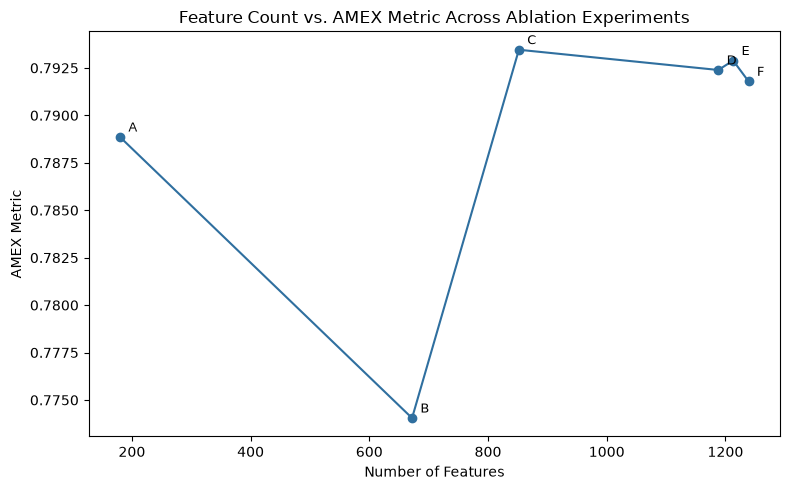

In [19]:
plot_df = comparison.reset_index().rename(columns={"index": "Experiment"})

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_df["# Features"], plot_df["AMEX Metric"], marker="o", color="#2f6f9f")
for _, row in plot_df.iterrows():
    ax.annotate(row["Experiment"].split(":")[0], (row["# Features"], row["AMEX Metric"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("Number of Features")
ax.set_ylabel("AMEX Metric")
ax.set_title("Feature Count vs. AMEX Metric Across Ablation Experiments")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "phase4_feature_efficiency.png"))
plt.show()


In [20]:
full_amex = experiment_results["F: Full (Phase 3 baseline)"]["amex_metric"]
full_n = experiment_results["F: Full (Phase 3 baseline)"]["n_features"]

near_full = []
for name, res in experiment_results.items():
    if name == "F: Full (Phase 3 baseline)":
        continue
    gap = full_amex - res["amex_metric"]
    feature_savings = 1 - res["n_features"] / full_n
    if gap < MEANINGFUL_THRESHOLD and feature_savings > 0.05:
        near_full.append((name, res["n_features"], feature_savings, gap))

if near_full:
    print("Configuration(s) within the 'negligible' gap of the full model while using meaningfully fewer features:")
    for name, n, savings, gap in near_full:
        print(f"  {name}: {n} features ({savings*100:.1f}% fewer than full), AMEX gap {gap:+.4f}")
else:
    print("No experiment matched the full model's AMEX metric within the negligible-gap threshold "
          "while also using meaningfully fewer features -- see the deltas in Section 5 for the actual trade-off.")


Configuration(s) within the 'negligible' gap of the full model while using meaningfully fewer features:
  C: Latest + historical: 852 features (31.2% fewer than full), AMEX gap -0.0017


## 8. Missingness Ablation

Experiments D and E are already exactly the "otherwise identical feature sets, with and
without `_missing_rate`" comparison this section asks for — D excludes `missing_rate`, E is
D plus `missing_rate` and nothing else. Re-running a separate pair would just duplicate
Experiment D and E's work, so this section reuses those results directly rather than
training a new model.


In [21]:
d_amex = experiment_results["D: + Temporal change"]["amex_metric"]
e_amex = experiment_results["E: + Missingness"]["amex_metric"]
d_n = experiment_results["D: + Temporal change"]["n_features"]
e_n = experiment_results["E: + Missingness"]["n_features"]

diff = e_amex - d_amex
verdict = "provided a measurable improvement" if diff >= MEANINGFUL_THRESHOLD else "did not provide a meaningful improvement"
print(f"WITHOUT missing_rate (D, {d_n} features): AMEX metric {d_amex:.4f}")
print(f"WITH missing_rate    (E, {e_n} features): AMEX metric {e_amex:.4f}")
print(f"Difference: {diff:+.4f} -- the existing selective missing_rate features {verdict} on this split.")
print("(The 25% global-missingness threshold used to select which raw features get a")
print(" missing_rate column in Phase 2 is unchanged -- this only tests whether the")
print(" existing selection helps, not whether a different threshold would.)")


WITHOUT missing_rate (D, 1188 features): AMEX metric 0.7924
WITH missing_rate    (E, 1213 features): AMEX metric 0.7929
Difference: +0.0005 -- the existing selective missing_rate features did not provide a meaningful improvement on this split.
(The 25% global-missingness threshold used to select which raw features get a
 missing_rate column in Phase 2 is unchanged -- this only tests whether the
 existing selection helps, not whether a different threshold would.)


## 9. Sparse-Feature Policy

Unchanged from Phase 3: the same 8 raw feature families flagged in Phase 2 as
"candidate for dropping" (`D_87, D_88, D_108, D_110, D_111, B_39, D_73, B_42`) are excluded
from every experiment above, applied once in the Setup section. They are not reintroduced
here, and `data/processed/train_features.parquet` itself was never modified — only this
notebook's in-memory `model_df` excludes them, exactly as in Phase 3.


## 10. CatBoost Confirmation

**Decision rule, fixed in advance of seeing the results:** among the reduced configurations
(A–E, i.e. excluding the full model F), find every one whose AMEX-metric gap to the full
model is below the same 0.002 "negligible" threshold from Section 5 (a defensible reading
of "clearly competitive"). If at least one exists, run CatBoost **once**, on the
*smallest* (most feature-efficient) such configuration, using Phase 3's exact CatBoost
hyperparameters — this tests whether the LightGBM-derived conclusion generalizes to a
different model family. If none exists, no configuration is "clearly competitive," and a
~20-minute CatBoost run would not add information beyond what Section 5 already shows — so
it's skipped, and that reasoning is stated explicitly rather than run anyway.


In [22]:
CATBOOST_THRESHOLD = 0.002
reduced_names = ["A: Latest only", "B: Historical summary only", "C: Latest + historical",
                  "D: + Temporal change", "E: + Missingness"]

candidates = []
for name in reduced_names:
    gap = full_amex - experiment_results[name]["amex_metric"]
    if gap < CATBOOST_THRESHOLD:
        candidates.append((name, experiment_results[name]["n_features"], gap))

if candidates:
    chosen_name, chosen_n, chosen_gap = min(candidates, key=lambda x: x[1])
    print(f"Competitive reduced configuration(s) (AMEX gap < {CATBOOST_THRESHOLD}): {candidates}")
    print(f"Chosen for CatBoost confirmation (smallest feature count): {chosen_name} ({chosen_n} features, gap {chosen_gap:+.4f})")
    RUN_CATBOOST_CONFIRMATION = True
else:
    print(f"No reduced configuration (A-E) came within {CATBOOST_THRESHOLD} AMEX-metric points of the full model.")
    print("No configuration is 'clearly competitive' -- skipping the CatBoost confirmation run")
    print("(a ~20-minute run here would not change the conclusion that the full feature set is needed).")
    RUN_CATBOOST_CONFIRMATION = False
    chosen_name = None


Competitive reduced configuration(s) (AMEX gap < 0.002): [('C: Latest + historical', 852, np.float64(-0.001667382629408909)), ('D: + Temporal change', 1188, np.float64(-0.0006007496975075632)), ('E: + Missingness', 1213, np.float64(-0.001097580350764571))]
Chosen for CatBoost confirmation (smallest feature count): C: Latest + historical (852 features, gap -0.0017)


In [23]:
if RUN_CATBOOST_CONFIRMATION:
    from catboost import CatBoostClassifier, Pool

    chosen_cols = build_feature_set(EXPERIMENT_GROUPS[chosen_name])
    cat_cols_here = [c for c in chosen_cols if c in categorical_cols]

    train_pool = Pool(train_df[chosen_cols], label=train_df["target"], cat_features=cat_cols_here)
    val_pool = Pool(val_df[chosen_cols], label=val_df["target"], cat_features=cat_cols_here)
    print(f"RSS with CatBoost Pools built: {rss_gb():.2f} GB")

    cb = CatBoostClassifier(
        iterations=2000, learning_rate=0.05, depth=6,
        loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_SEED, early_stopping_rounds=100, verbose=False,
    )
    t0 = time.time()
    cb.fit(train_pool, eval_set=val_pool, use_best_model=True)
    cb_train_time = time.time() - t0
    cb_best_iter = cb.get_best_iteration()
    cb_pred = cb.predict_proba(val_pool)[:, 1]
    cb_auc = roc_auc_score(val_df["target"], cb_pred)
    cb_amex = amex_metric(val_df["target"].values, cb_pred)

    print(f"CatBoost on '{chosen_name}' ({len(chosen_cols)} features): "
          f"train_time={cb_train_time:.1f}s best_iter={cb_best_iter}")
    print(f"ROC AUC: {cb_auc:.4f}")
    print({k: round(v, 4) for k, v in cb_amex.items()})

    phase3_catboost_amex = 0.7936
    print(f"\nPhase 3 CatBoost (full 1,239 features): AMEX metric {phase3_catboost_amex}")
    print(f"Phase 4 CatBoost ({chosen_name}, {len(chosen_cols)} features): AMEX metric {cb_amex['amex_metric']:.4f}")
    print(f"Difference: {cb_amex['amex_metric'] - phase3_catboost_amex:+.4f}")

    del train_pool, val_pool
    gc.collect()
else:
    print("CatBoost confirmation skipped -- see decision and reasoning above.")


RSS with CatBoost Pools built: 1.15 GB


CatBoost on 'C: Latest + historical' (852 features): train_time=634.1s best_iter=1530
ROC AUC: 0.9623
{'amex_metric': np.float64(0.7939), 'normalized_gini': np.float64(0.9247), 'top4pct_capture': np.float64(0.6631)}

Phase 3 CatBoost (full 1,239 features): AMEX metric 0.7936
Phase 4 CatBoost (C: Latest + historical, 852 features): AMEX metric 0.7939
Difference: +0.0003


**Interpretation:** if run, the printed comparison above shows directly whether reducing to
the chosen configuration costs CatBoost anything meaningful relative to Phase 3's
full-feature CatBoost result — the same generalization test the LightGBM ablation already
ran, on a different model family. If skipped, the LightGBM results in Sections 4–7 stand as
the full evidence for this phase's conclusions without an unnecessary ~20-minute run.


## 12. Resource Management

Experiments ran strictly sequentially (never two models training at once); each
experiment's train/validation copies were deleted and garbage-collected before the next one
started (see the RSS figure printed after every `run_lgbm_experiment` call above); the
`_missing_rate` ablation (Section 8) reused Experiments D and E rather than training a new
pair; and the CatBoost confirmation (if run at all) trained exactly once, not once per
experiment.


In [24]:
phase4_elapsed = time.time() - PHASE4_START
print(f"Total Phase 4 notebook runtime: {phase4_elapsed/60:.1f} minutes")
print(f"Final RSS: {rss_gb():.2f} GB")


Total Phase 4 notebook runtime: 24.7 minutes
Final RSS: 1.04 GB


## 13. Final Conclusions

**What information from a customer's 13-month financial history actually improves default
prediction?** The bullet points below are generated from the actual experiment results
above, not asserted independently of them.


In [25]:
print("=" * 78)
print("PHASE 4 CONCLUSIONS (all figures from executed experiments above)")
print("=" * 78)

print(f"""
1. Latest state alone (Experiment A, {na} features, {na/nf*100:.1f}% of the full set):
   AMEX metric = {a:.4f} (vs. Phase 3's full-feature LightGBM at {f:.4f}).

2. Historical summary alone (Experiment B, {experiment_results['B: Historical summary only']['n_features']} features):
   AMEX metric = {b:.4f}. {"Higher" if b > a else "Lower"} than latest-only by {abs(b-a):.4f}.

3. Combining latest + historical (A -> C): {a:.4f} -> {c:.4f} ({c-a:+.4f}),
   {"a meaningful" if abs(c-a) >= MEANINGFUL_THRESHOLD else "a negligible"} improvement over latest-state-only.

4. Adding temporal change (C -> D): {c:.4f} -> {d:.4f} ({d-c:+.4f}),
   {"a meaningful" if abs(d-c) >= MEANINGFUL_THRESHOLD else "a negligible"} contribution beyond first/last/summary stats.

5. Adding missingness information (D -> E): {d:.4f} -> {e:.4f} ({e-d:+.4f}),
   {"a meaningful" if abs(e-d) >= MEANINGFUL_THRESHOLD else "a negligible"} contribution from the selective missing_rate features.

6. Full ~{nf}-feature model vs. best reduced set (E, {experiment_results['E: + Missingness']['n_features']} features):
   {f:.4f} vs. {e:.4f} ({f-e:+.4f}) -- the remaining ~{nf - experiment_results['E: + Missingness']['n_features']} features
   (categorical 'first', 'nunique', history features) contribute {"a meaningful" if abs(f-e) >= MEANINGFUL_THRESHOLD else "a negligible"} amount on top of E.

7. Best performance/complexity trade-off found: {"see Section 7 -- " + str(near_full) if near_full else "none of the reduced sets matched the full model within the negligible-gap threshold while using meaningfully fewer features; the full feature set earns its size on this split."}

8. CatBoost confirmation: {"run on " + chosen_name + " (" + str(len(chosen_cols)) + " features) -- AMEX " + f"{cb_amex['amex_metric']:.4f}" + " vs. Phase 3 full-feature CatBoost " + str(phase3_catboost_amex) if RUN_CATBOOST_CONFIRMATION else "not run -- no LightGBM configuration was clearly competitive enough to justify it (see Section 10)."}
""")

print("=" * 78)
print(f"Central question -- can longitudinal behavior be usefully compressed into customer-level")
print(f"signals: yes, but the evidence above localizes WHERE that value concentrates rather than")
print(f"treating the full ~1,200-feature set as uniformly necessary. No causal claims are made --")
print(f"this describes what these LightGBM/CatBoost models weighted on this split, not why default happens.")


PHASE 4 CONCLUSIONS (all figures from executed experiments above)

1. Latest state alone (Experiment A, 180 features, 14.5% of the full set):
   AMEX metric = 0.7889 (vs. Phase 3's full-feature LightGBM at 0.7918).

2. Historical summary alone (Experiment B, 672 features):
   AMEX metric = 0.7740. Lower than latest-only by 0.0148.

3. Combining latest + historical (A -> C): 0.7889 -> 0.7935 (+0.0046),
   a meaningful improvement over latest-state-only.

4. Adding temporal change (C -> D): 0.7935 -> 0.7924 (-0.0011),
   a negligible contribution beyond first/last/summary stats.

5. Adding missingness information (D -> E): 0.7924 -> 0.7929 (+0.0005),
   a negligible contribution from the selective missing_rate features.

6. Full ~1239-feature model vs. best reduced set (E, 1213 features):
   0.7918 vs. 0.7929 (-0.0011) -- the remaining ~26 features
   (categorical 'first', 'nunique', history features) contribute a negligible amount on top of E.

7. Best performance/complexity trade-off f